<a href="https://colab.research.google.com/github/orcasandpandas/Data-Science-Cohort-20/blob/main/Project_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 4: Music Popularity Prediction


This project will take data features collected for songs that have been on the Top 200 Weekly (Global) charts of Spotify in 2020 & 2021. The popularity of the song will be predicted using a tree-based regression model trained on these features.



The goals for the project are:

- Minimize the cross-validated ***root mean squared error ( RMSE )*** when predicting the popularity of a new song.

- Determine the importance of the features in driving the regression result.
The project will be done using tree-based regression techniques as covered in class. The hyperparameters of the trees should be carefully selected to avoid over-fitting.


There are three main challenges for this project:

1. Determining the outcome ( i.e. target ).  There is a "popularity" column.  But other columns may or may not be more appropriate indicators of popularity.

1. Choosing appropriate predictors ( i.e. features ). When building a machine learning model, we want to make sure that we consider how the model will be ultimately used. For this project, we are predicting the popularity of a new song. Therefore, we should only include the predictors we would have for a new song. It might help to imagine that the song will not be released for several weeks.

1. Data cleaning and feature engineering. Some creative cleaning and/or feature engineering may be needed to extract useful information for prediction.



## Data Collection/Sources

Once again, be sure to go through the whole data science process and document as such in your Jupyter notebook.

The data is available AWS at https://ddc-datascience.s3.amazonaws.com/Projects/Project.4-Spotify/Data/Spotify.csv .



### Data Importing

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn import datasets
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn import metrics

from sklearn.metrics import mean_squared_error

In [ ]:
url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.4-Spotify/Data/Spotify.csv"
!curl -s -I {url}

HTTP/1.1 200 OK
x-amz-id-2: Jwcwd1353r8T42W6Rw7lm2GVHxNqg1Dz6I9YrxMtBBL07I87Ev4CmwWXhFQz6c9aB85s9OVBAug=
x-amz-request-id: Y6WGGYPMAA1447ZD
Date: Fri, 29 May 2026 19:12:00 GMT
Last-Modified: Wed, 04 Oct 2023 17:23:56 GMT
ETag: "65b9875b11e0d7ea03ee2af024f45e99"
x-amz-server-side-encryption: AES256
Accept-Ranges: bytes
Content-Type: text/csv
Content-Length: 738124
Server: AmazonS3



Curl can get data from a page automatically

### Data Composition

In [ ]:
df = pd.read_csv(url)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1556 entries, 0 to 1555
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Index                      1556 non-null   int64 
 1   Highest Charting Position  1556 non-null   int64 
 2   Number of Times Charted    1556 non-null   int64 
 3   Week of Highest Charting   1556 non-null   object
 4   Song Name                  1556 non-null   object
 5   Streams                    1556 non-null   object
 6   Artist                     1556 non-null   object
 7   Artist Followers           1556 non-null   object
 8   Song ID                    1556 non-null   object
 9   Genre                      1556 non-null   object
 10  Release Date               1556 non-null   object
 11  Weeks Charted              1556 non-null   object
 12  Popularity                 1556 non-null   object
 13  Danceability               1556 non-null   object
 14  Energy  

From what we see, most of the data is not null, but a lot of variables that are numerical are viewed as objects...

In [ ]:
df.head().T

,0,1,2,3,4
Index,1,2,3,4,5
Highest Charting Position,1,2,1,3,5
Number of Times Charted,8,3,11,5,1
Week of Highest Charting,2021-07-23--2021-07-30,2021-07-23--2021-07-30,2021-06-25--2021-07-02,2021-07-02--2021-07-09,2021-07-23--2021-07-30
Song Name,Beggin',STAY (with Justin Bieber),good 4 u,Bad Habits,INDUSTRY BABY (feat. Jack Harlow)
Streams,"48,633,449","47,248,719","40,162,559","37,799,456","33,948,454"
Artist,Måneskin,The Kid LAROI,Olivia Rodrigo,Ed Sheeran,Lil Nas X
Artist Followers,3377762,2230022,6266514,83293380,5473565
Song ID,3Wrjm47oTz2sjIgck11l5e,5HCyWlXZPP0y6Gqq8TgA20,4ZtFanR9U6ndgddUvNcjcG,6PQ88X9TkUIAUIZJHW2upE,27NovPIUIRrOZoCHxABJwK
Genre,"['indie rock italiano', 'italian pop']",['australian hip hop'],['pop'],"['pop', 'uk pop']","['lgbtq+ hip hop', 'pop rap']"


In [ ]:
df.tail().T

,1551,1552,1553,1554,1555
Index,1552,1553,1554,1555,1556
Highest Charting Position,195,196,197,198,199
Number of Times Charted,1,1,1,1,1
Week of Highest Charting,2019-12-27--2020-01-03,2019-12-27--2020-01-03,2019-12-27--2020-01-03,2019-12-27--2020-01-03,2019-12-27--2020-01-03
Song Name,New Rules,Cheirosa - Ao Vivo,Havana (feat. Young Thug),Surtada - Remix Brega Funk,Lover (Remix) [feat. Shawn Mendes]
Streams,"4,630,675","4,623,030","4,620,876","4,607,385","4,595,450"
Artist,Dua Lipa,Jorge & Mateus,Camila Cabello,"Dadá Boladão, Tati Zaqui, OIK",Taylor Swift
Artist Followers,27167675,15019109,22698747,208630,42227614
Song ID,2ekn2ttSfGqwhhate0LSR0,2PWjKmjyTZeDpmOUa3a5da,1rfofaqEpACxVEHIZBJe6W,5F8ffc8KWKNawllr5WsW0r,3i9UVldZOE0aD0JnyfAZZ0
Genre,"['dance pop', 'pop', 'uk pop']","['sertanejo', 'sertanejo universitario']","['dance pop', 'electropop', 'pop', 'post-teen ...","['brega funk', 'funk carioca']","['pop', 'post-teen pop']"


This gives us a general look at how the data is formatted, and a good idea of what changes will be needed later on

In [ ]:
df.isna().sum().sort_values(ascending=False)*100/len(df)


,0
Index,0.0
Highest Charting Position,0.0
Number of Times Charted,0.0
Week of Highest Charting,0.0
Song Name,0.0
Streams,0.0
Artist,0.0
Artist Followers,0.0
Song ID,0.0
Genre,0.0


No nulls here, interestingly

In [ ]:
df.nunique().sort_values( ascending = False )

,0
Index,1556
Streams,1556
Song Name,1556
Song ID,1517
Duration (ms),1486
Tempo,1461
Loudness,1394
Acousticness,965
Weeks Charted,775
Speechiness,772


Any value thats nunique and not a continous number is likely extraneous

## Data Cleaning

### Fixing Numerical Columns

In [ ]:
bak_01 = df.copy()

In [ ]:
df['Streams'] = df['Streams'].str.replace(',', "", regex = False)
df['Streams']

,Streams
0,48633449
1,47248719
2,40162559
3,37799456
4,33948454
...,...
1551,4630675
1552,4623030
1553,4620876
1554,4607385


Streams has to have commas removed so that it can be properly processed

In [ ]:
# List of objects that represent numeric values
obj_to_int = ['Streams', 'Artist Followers', 'Popularity', 'Danceability', 'Energy', 'Loudness', 'Speechiness', 'Acousticness', 'Liveness', 'Tempo', 'Duration (ms)', 'Valence']

# This regular expression deletes everything that isn't a digit, a period, or a negative sign
df[obj_to_int] = df[obj_to_int].replace(r'[^0-9.-]', '', regex = True)
df[obj_to_int]

,Streams,Artist Followers,Popularity,Danceability,Energy,Loudness,Speechiness,Acousticness,Liveness,Tempo,Duration (ms),Valence
0,48633449,3377762,100,0.714,0.8,-4.808,0.0504,0.127,0.359,134.002,211560,0.589
1,47248719,2230022,99,0.591,0.764,-5.484,0.0483,0.0383,0.103,169.928,141806,0.478
2,40162559,6266514,99,0.563,0.664,-5.044,0.154,0.335,0.0849,166.928,178147,0.688
3,37799456,83293380,98,0.808,0.897,-3.712,0.0348,0.0469,0.364,126.026,231041,0.591
4,33948454,5473565,96,0.736,0.704,-7.409,0.0615,0.0203,0.0501,149.995,212000,0.894
...,...,...,...,...,...,...,...,...,...,...,...,...
1551,4630675,27167675,79,0.762,0.7,-6.021,0.0694,0.00261,0.153,116.073,209320,0.608
1552,4623030,15019109,66,0.528,0.87,-3.123,0.0851,0.24,0.333,152.37,181930,0.714
1553,4620876,22698747,81,0.765,0.523,-4.333,0.03,0.184,0.132,104.988,217307,0.394
1554,4607385,208630,60,0.832,0.55,-7.026,0.0587,0.249,0.182,154.064,152784,0.881


Numbers with anything other than digits or a minus sign can't be processed, so any character that isn't one of those things gets removed!

In [ ]:
# This regex removes all minus signs that are not at the beginning of the number
df[obj_to_int] = df[obj_to_int].replace(r'(?<!^)-', '', regex = True)

df[obj_to_int] = df[obj_to_int].apply(pd.to_numeric)

df[obj_to_int]

,Streams,Artist Followers,Popularity,Danceability,Energy,Loudness,Speechiness,Acousticness,Liveness,Tempo,Duration (ms),Valence
0,48633449,3377762.0,100.0,0.714,0.800,-4.808,0.0504,0.12700,0.3590,134.002,211560.0,0.589
1,47248719,2230022.0,99.0,0.591,0.764,-5.484,0.0483,0.03830,0.1030,169.928,141806.0,0.478
2,40162559,6266514.0,99.0,0.563,0.664,-5.044,0.1540,0.33500,0.0849,166.928,178147.0,0.688
3,37799456,83293380.0,98.0,0.808,0.897,-3.712,0.0348,0.04690,0.3640,126.026,231041.0,0.591
4,33948454,5473565.0,96.0,0.736,0.704,-7.409,0.0615,0.02030,0.0501,149.995,212000.0,0.894
...,...,...,...,...,...,...,...,...,...,...,...,...
1551,4630675,27167675.0,79.0,0.762,0.700,-6.021,0.0694,0.00261,0.1530,116.073,209320.0,0.608
1552,4623030,15019109.0,66.0,0.528,0.870,-3.123,0.0851,0.24000,0.3330,152.370,181930.0,0.714
1553,4620876,22698747.0,81.0,0.765,0.523,-4.333,0.0300,0.18400,0.1320,104.988,217307.0,0.394
1554,4607385,208630.0,60.0,0.832,0.550,-7.026,0.0587,0.24900,0.1820,154.064,152784.0,0.881


One issue is some minus signs are inside the number (ex: 0.7-453) but fortunately the right regular expression can deal with those as well

In [ ]:
# Decimals are limited to 2 places for better readability
df.describe().apply(lambda n: n.apply('{0:.2f}'.format)).T

,count,mean,std,min,25%,50%,75%,max
Index,1556.00,778.50,449.32,1.00,389.75,778.50,1167.25,1556.00
Highest Charting Position,1556.00,87.74,58.15,1.00,37.00,80.00,137.00,200.00
Number of Times Charted,1556.00,10.67,16.36,1.00,1.00,4.00,12.00,142.00
Streams,1556.00,6340219.38,3369478.84,4176083.00,4915322.25,5275747.50,6455044.25,48633449.00
Artist Followers,1545.00,14716902.87,16675788.51,4883.00,2123734.00,6852509.00,22698747.00,83337783.00
Popularity,1545.00,70.09,15.82,0.00,65.00,73.00,80.00,100.00
Danceability,1545.00,0.69,0.14,0.15,0.60,0.71,0.80,0.98
Energy,1545.00,0.63,0.16,0.05,0.53,0.64,0.75,0.97
Loudness,1545.00,-6.35,2.51,-25.17,-7.49,-5.99,-4.71,1.51
Speechiness,1545.00,0.12,0.11,0.02,0.05,0.08,0.17,0.88


Looking at the stats, there don't seem to be any serious disrepancies as most numbers have a minimum value above 0 (except for popularity) and there don't seem to be any egregious outliers

### Fixing Date Columns

In [ ]:
bak_02 = df.copy()

In [ ]:
# Turns this column into the date object, removing whitespace and checking for various date formats
df['Release Date'] = pd.to_datetime(df['Release Date'].str.strip(), format='mixed')

In [ ]:
# Grabs only the first date of the peak week, removing the second one
df['Week of Highest Charting Start'] = df['Week of Highest Charting'].str.split('--').str[0]

# Convert it to datetime so we can actually use it
df['Week of Highest Charting Start'] = pd.to_datetime(df['Week of Highest Charting Start'].str.strip())

To process the dates, proper formatting is needed!

In [ ]:
df.T

,0,1,2,3,4,5,6,7,8,9,...,1546,1547,1548,1549,1550,1551,1552,1553,1554,1555
Index,1,2,3,4,5,6,7,8,9,10,...,1547,1548,1549,1550,1551,1552,1553,1554,1555,1556
Highest Charting Position,1,2,1,3,5,1,3,2,3,8,...,143,156,178,187,190,195,196,197,198,199
Number of Times Charted,8,3,11,5,1,18,16,10,8,10,...,1,1,1,1,1,1,1,1,1,1
Week of Highest Charting,2021-07-23--2021-07-30,2021-07-23--2021-07-30,2021-06-25--2021-07-02,2021-07-02--2021-07-09,2021-07-23--2021-07-30,2021-05-07--2021-05-14,2021-05-14--2021-05-21,2021-06-18--2021-06-25,2021-06-18--2021-06-25,2021-07-02--2021-07-09,...,2019-12-27--2020-01-03,2019-12-27--2020-01-03,2019-12-27--2020-01-03,2019-12-27--2020-01-03,2019-12-27--2020-01-03,2019-12-27--2020-01-03,2019-12-27--2020-01-03,2019-12-27--2020-01-03,2019-12-27--2020-01-03,2019-12-27--2020-01-03
Song Name,Beggin',STAY (with Justin Bieber),good 4 u,Bad Habits,INDUSTRY BABY (feat. Jack Harlow),MONTERO (Call Me By Your Name),Kiss Me More (feat. SZA),Todo De Ti,Yonaguni,I WANNA BE YOUR SLAVE,...,JACKBOYS,Combatchy (feat. MC Rebecca),Old Town Road,Let Me Know (I Wonder Why Freestyle),Ne reviens pas,New Rules,Cheirosa - Ao Vivo,Havana (feat. Young Thug),Surtada - Remix Brega Funk,Lover (Remix) [feat. Shawn Mendes]
Streams,48633449,47248719,40162559,37799456,33948454,30071134,29356736,26951613,25030128,24551591,...,5363493,5149797,4852004,4701532,4676857,4630675,4623030,4620876,4607385,4595450
Artist,Måneskin,The Kid LAROI,Olivia Rodrigo,Ed Sheeran,Lil Nas X,Lil Nas X,Doja Cat,Rauw Alejandro,Bad Bunny,Måneskin,...,JACKBOYS,"Anitta, Lexa, Luísa Sonza",Lil Nas X,Juice WRLD,"Gradur, Heuss L'enfoiré",Dua Lipa,Jorge & Mateus,Camila Cabello,"Dadá Boladão, Tati Zaqui, OIK",Taylor Swift
Artist Followers,3377762.0,2230022.0,6266514.0,83293380.0,5473565.0,5473565.0,8640063.0,6080597.0,36142273.0,3377762.0,...,437907.0,10741972.0,5488666.0,19102888.0,1390813.0,27167675.0,15019109.0,22698747.0,208630.0,42227614.0
Song ID,3Wrjm47oTz2sjIgck11l5e,5HCyWlXZPP0y6Gqq8TgA20,4ZtFanR9U6ndgddUvNcjcG,6PQ88X9TkUIAUIZJHW2upE,27NovPIUIRrOZoCHxABJwK,67BtfxlNbhBmCDR2L2l8qd,748mdHapucXQri7IAO8yFK,4fSIb4hdOQ151TILNsSEaF,2JPLbjOn0wPCngEot2STUS,4pt5fDVTg5GhEvEtlz9dKk,...,62zKJrpbLxz6InR3tGyr7o,2bPtwnrpFNEe8N7Q85kLHw,2YpeDb67231RjR0MgVLzsG,3wwo0bJvDSorOpNfzEkfXx,4TnFANpjVwVKWzkxNzIyFH,2ekn2ttSfGqwhhate0LSR0,2PWjKmjyTZeDpmOUa3a5da,1rfofaqEpACxVEHIZBJe6W,5F8ffc8KWKNawllr5WsW0r,3i9UVldZOE0aD0JnyfAZZ0
Genre,"['indie rock italiano', 'italian pop']",['australian hip hop'],['pop'],"['pop', 'uk pop']","['lgbtq+ hip hop', 'pop rap']","['lgbtq+ hip hop', 'pop rap']","['dance pop', 'pop']","['puerto rican pop', 'trap latino']","['latin', 'reggaeton', 'trap latino']","['indie rock italiano', 'italian pop']",...,"['rap', 'trap']","['funk carioca', 'funk pop', 'pagode baiano', ...","['lgbtq+ hip hop', 'pop rap']","['chicago rap', 'melodic rap']","['francoton', 'french hip hop', 'pop urbaine',...","['dance pop', 'pop', 'uk pop']","['sertanejo', 'sertanejo universitario']","['dance pop', 'electropop', 'pop', 'post-teen ...","['brega funk', 'funk carioca']","['pop', 'post-teen pop']"


In [ ]:
df = df.drop(columns=["Weeks Charted", "Week of Highest Charting"])

Weeks Charted is too hard to process and week of highest charting is easier used when only the first week is displayed (since a week is only seven days, the second date is not needed)

In [ ]:
df.T

,0,1,2,3,4,5,6,7,8,9,...,1546,1547,1548,1549,1550,1551,1552,1553,1554,1555
Index,1,2,3,4,5,6,7,8,9,10,...,1547,1548,1549,1550,1551,1552,1553,1554,1555,1556
Highest Charting Position,1,2,1,3,5,1,3,2,3,8,...,143,156,178,187,190,195,196,197,198,199
Number of Times Charted,8,3,11,5,1,18,16,10,8,10,...,1,1,1,1,1,1,1,1,1,1
Song Name,Beggin',STAY (with Justin Bieber),good 4 u,Bad Habits,INDUSTRY BABY (feat. Jack Harlow),MONTERO (Call Me By Your Name),Kiss Me More (feat. SZA),Todo De Ti,Yonaguni,I WANNA BE YOUR SLAVE,...,JACKBOYS,Combatchy (feat. MC Rebecca),Old Town Road,Let Me Know (I Wonder Why Freestyle),Ne reviens pas,New Rules,Cheirosa - Ao Vivo,Havana (feat. Young Thug),Surtada - Remix Brega Funk,Lover (Remix) [feat. Shawn Mendes]
Streams,48633449,47248719,40162559,37799456,33948454,30071134,29356736,26951613,25030128,24551591,...,5363493,5149797,4852004,4701532,4676857,4630675,4623030,4620876,4607385,4595450
Artist,Måneskin,The Kid LAROI,Olivia Rodrigo,Ed Sheeran,Lil Nas X,Lil Nas X,Doja Cat,Rauw Alejandro,Bad Bunny,Måneskin,...,JACKBOYS,"Anitta, Lexa, Luísa Sonza",Lil Nas X,Juice WRLD,"Gradur, Heuss L'enfoiré",Dua Lipa,Jorge & Mateus,Camila Cabello,"Dadá Boladão, Tati Zaqui, OIK",Taylor Swift
Artist Followers,3377762.0,2230022.0,6266514.0,83293380.0,5473565.0,5473565.0,8640063.0,6080597.0,36142273.0,3377762.0,...,437907.0,10741972.0,5488666.0,19102888.0,1390813.0,27167675.0,15019109.0,22698747.0,208630.0,42227614.0
Song ID,3Wrjm47oTz2sjIgck11l5e,5HCyWlXZPP0y6Gqq8TgA20,4ZtFanR9U6ndgddUvNcjcG,6PQ88X9TkUIAUIZJHW2upE,27NovPIUIRrOZoCHxABJwK,67BtfxlNbhBmCDR2L2l8qd,748mdHapucXQri7IAO8yFK,4fSIb4hdOQ151TILNsSEaF,2JPLbjOn0wPCngEot2STUS,4pt5fDVTg5GhEvEtlz9dKk,...,62zKJrpbLxz6InR3tGyr7o,2bPtwnrpFNEe8N7Q85kLHw,2YpeDb67231RjR0MgVLzsG,3wwo0bJvDSorOpNfzEkfXx,4TnFANpjVwVKWzkxNzIyFH,2ekn2ttSfGqwhhate0LSR0,2PWjKmjyTZeDpmOUa3a5da,1rfofaqEpACxVEHIZBJe6W,5F8ffc8KWKNawllr5WsW0r,3i9UVldZOE0aD0JnyfAZZ0
Genre,"['indie rock italiano', 'italian pop']",['australian hip hop'],['pop'],"['pop', 'uk pop']","['lgbtq+ hip hop', 'pop rap']","['lgbtq+ hip hop', 'pop rap']","['dance pop', 'pop']","['puerto rican pop', 'trap latino']","['latin', 'reggaeton', 'trap latino']","['indie rock italiano', 'italian pop']",...,"['rap', 'trap']","['funk carioca', 'funk pop', 'pagode baiano', ...","['lgbtq+ hip hop', 'pop rap']","['chicago rap', 'melodic rap']","['francoton', 'french hip hop', 'pop urbaine',...","['dance pop', 'pop', 'uk pop']","['sertanejo', 'sertanejo universitario']","['dance pop', 'electropop', 'pop', 'post-teen ...","['brega funk', 'funk carioca']","['pop', 'post-teen pop']"
Release Date,2017-12-08 00:00:00,2021-07-09 00:00:00,2021-05-21 00:00:00,2021-06-25 00:00:00,2021-07-23 00:00:00,2021-03-31 00:00:00,2021-04-09 00:00:00,2021-05-20 00:00:00,2021-06-04 00:00:00,2021-03-19 00:00:00,...,2019-12-27 00:00:00,2019-11-20 00:00:00,2019-06-21 00:00:00,2019-12-07 00:00:00,2019-11-29 00:00:00,2017-06-02 00:00:00,2019-10-11 00:00:00,2018-01-12 00:00:00,2019-09-25 00:00:00,2019-11-13 00:00:00


For the week of highest charting, we only need the first date since a week is always going to be seven days!

### Handling categoricals

In [ ]:
bak03 = df.copy()

In [ ]:
df['Genre'] = df['Genre'].astype('category')
df['Genre']

,Genre
0,"['indie rock italiano', 'italian pop']"
1,['australian hip hop']
2,['pop']
3,"['pop', 'uk pop']"
4,"['lgbtq+ hip hop', 'pop rap']"
...,...
1551,"['dance pop', 'pop', 'uk pop']"
1552,"['sertanejo', 'sertanejo universitario']"
1553,"['dance pop', 'electropop', 'pop', 'post-teen ..."
1554,"['brega funk', 'funk carioca']"


In [ ]:
test_df = df[['Genre']].copy()
test_df

,Genre
0,"['indie rock italiano', 'italian pop']"
1,['australian hip hop']
2,['pop']
3,"['pop', 'uk pop']"
4,"['lgbtq+ hip hop', 'pop rap']"
...,...
1551,"['dance pop', 'pop', 'uk pop']"
1552,"['sertanejo', 'sertanejo universitario']"
1553,"['dance pop', 'electropop', 'pop', 'post-teen ..."
1554,"['brega funk', 'funk carioca']"


Looking at the genre categories, many are lists and have redundant labels like "post-teen pop" existing alongside "pop"

In [ ]:
test_df['Genre'] = (
    test_df['Genre']
    .astype(str)
    .str.replace(r"[\[\]']", "", regex=True) # Strips [, ], and '
    .str.split(", ")                         # Turns the string into a real list
)

In [ ]:
test_df = test_df.explode('Genre')
test_df

,Genre
0,indie rock italiano
0,italian pop
1,australian hip hop
2,pop
3,pop
...,...
1553,post-teen pop
1554,brega funk
1554,funk carioca
1555,pop


In [ ]:
df = df.drop(columns = ["Genre", "Index", "Chord", "Song Name", "Popularity", "Artist", "Song ID"])

Artist column feels unecessary since many albums have multiple artists, chord seems like fluff and popularity's parameters are unknown.  The other removed columns are either not worth the processing or are redundant identifiers

In [ ]:
df = df.drop(columns = ["Week of Highest Charting Start", "Release Date"])

The tree models don't work well with dates, so those will be taken out as well

In [ ]:
df

,Highest Charting Position,Number of Times Charted,Streams,Artist Followers,Danceability,Energy,Loudness,Speechiness,Acousticness,Liveness,Tempo,Duration (ms),Valence
0,1,8,48633449,3377762.0,0.714,0.800,-4.808,0.0504,0.12700,0.3590,134.002,211560.0,0.589
1,2,3,47248719,2230022.0,0.591,0.764,-5.484,0.0483,0.03830,0.1030,169.928,141806.0,0.478
2,1,11,40162559,6266514.0,0.563,0.664,-5.044,0.1540,0.33500,0.0849,166.928,178147.0,0.688
3,3,5,37799456,83293380.0,0.808,0.897,-3.712,0.0348,0.04690,0.3640,126.026,231041.0,0.591
4,5,1,33948454,5473565.0,0.736,0.704,-7.409,0.0615,0.02030,0.0501,149.995,212000.0,0.894
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1551,195,1,4630675,27167675.0,0.762,0.700,-6.021,0.0694,0.00261,0.1530,116.073,209320.0,0.608
1552,196,1,4623030,15019109.0,0.528,0.870,-3.123,0.0851,0.24000,0.3330,152.370,181930.0,0.714
1553,197,1,4620876,22698747.0,0.765,0.523,-4.333,0.0300,0.18400,0.1320,104.988,217307.0,0.394
1554,198,1,4607385,208630.0,0.832,0.550,-7.026,0.0587,0.24900,0.1820,154.064,152784.0,0.881


In [ ]:
df = df.dropna()

## Exploratory Data Analysis

### Graphing Variables

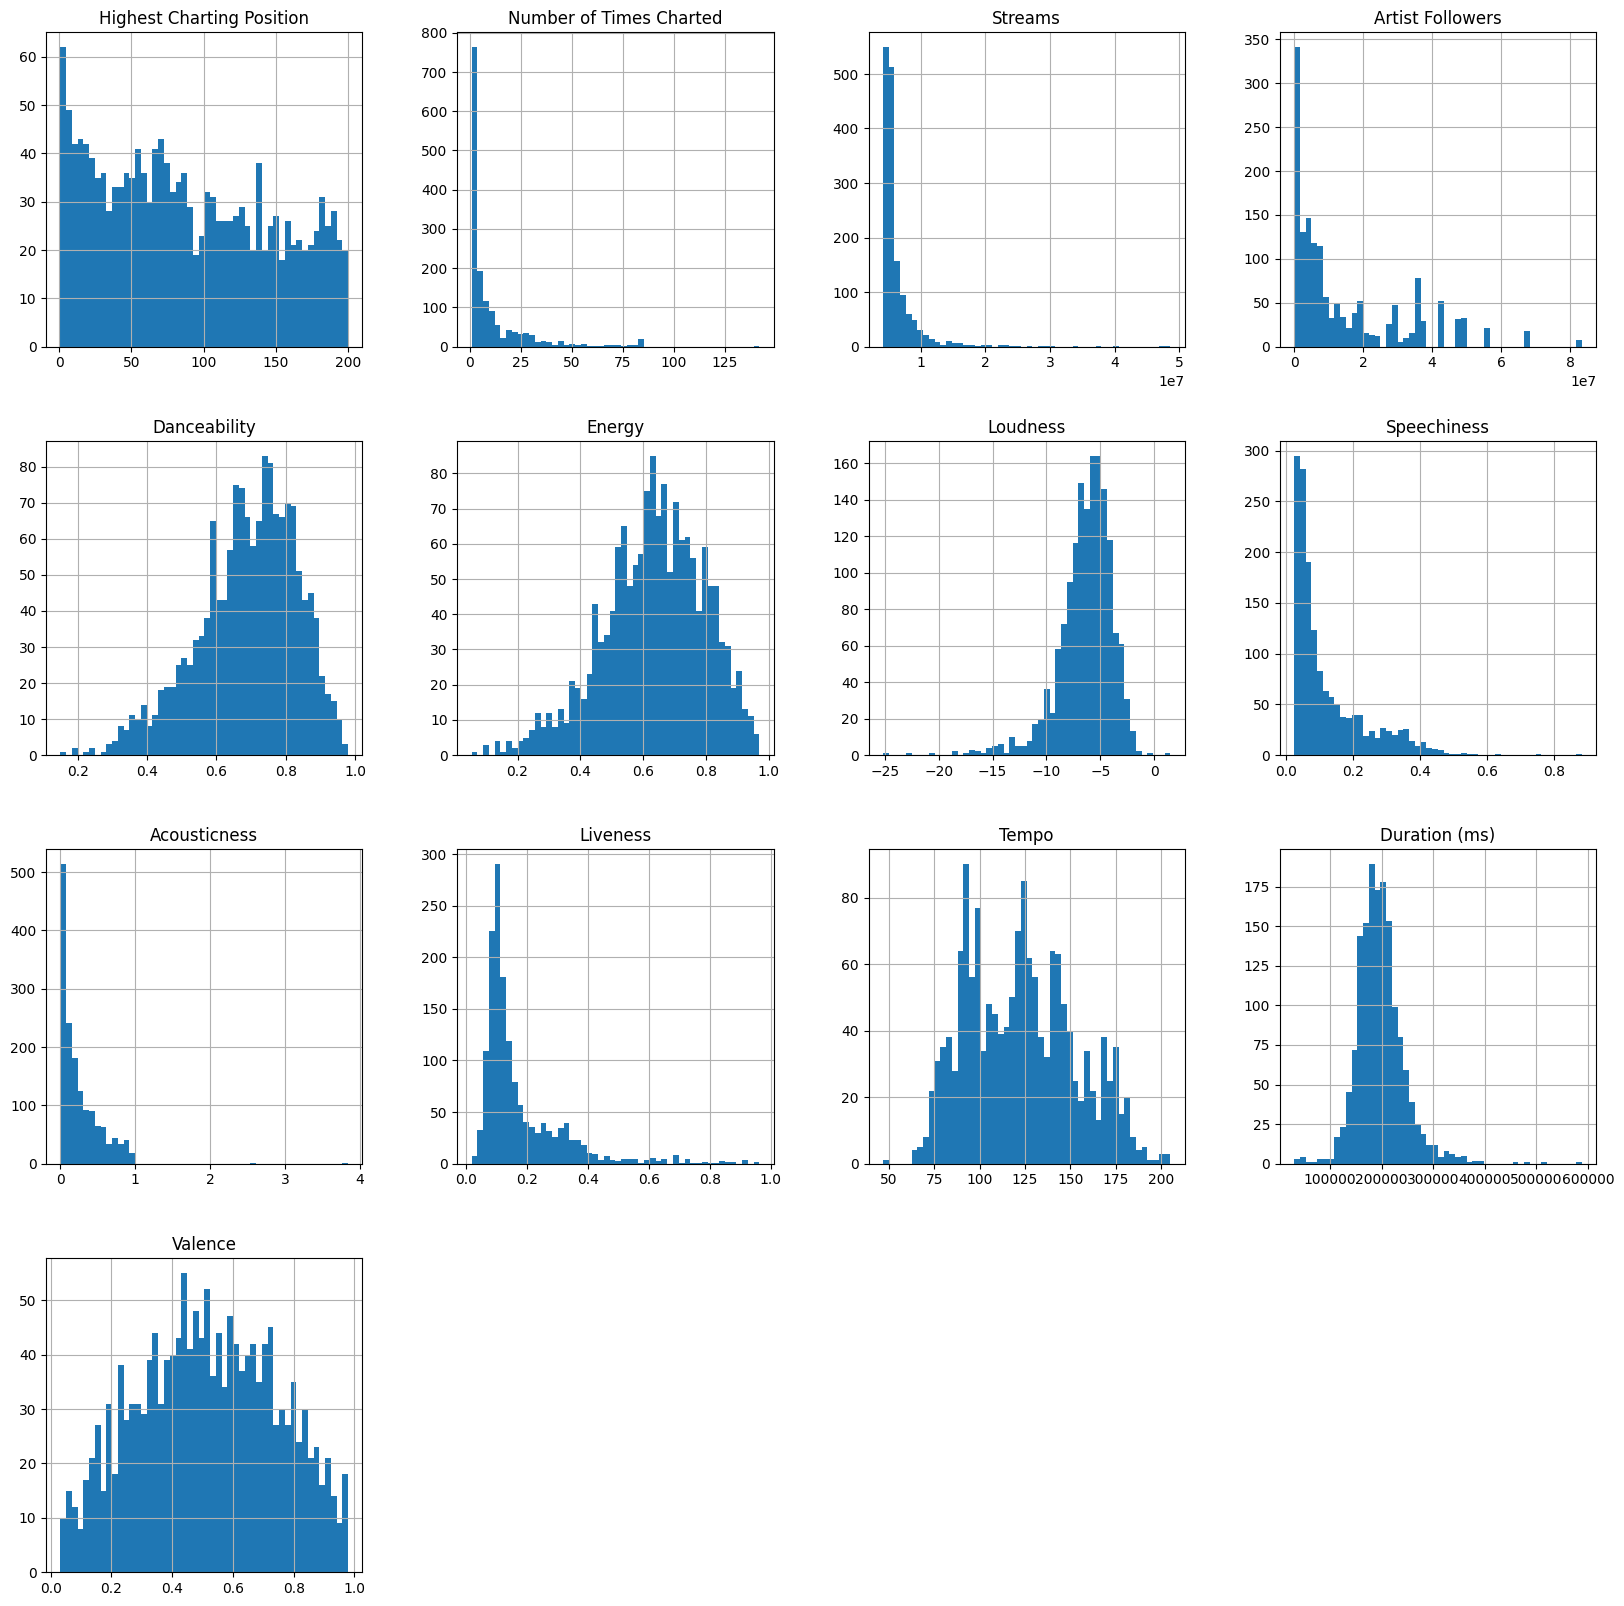

In [ ]:
df.hist(figsize=(20, 20), bins=50)
plt.show()

Looking at the graphs of our variables, it seems nothing is too out of the ordinary.  They all seem to follow some sort of distribution, though the skews are different

### Correlation Checking

In [ ]:
pred_corr = df.drop("Streams", axis = 1).corr().abs()
# Sliced like a sandwich
tri_mask = np.triu(np.ones_like(pred_corr, dtype = bool), k=1)
tri_corr = pred_corr.where(tri_mask)
rank_corr = tri_corr.unstack().dropna().sort_values(ascending=False)
rank_corr

Loudness                 Energy                       0.732616
Acousticness             Energy                       0.470136
                         Loudness                     0.446944
Number of Times Charted  Highest Charting Position    0.417748
Valence                  Danceability                 0.361627
                                                        ...   
Liveness                 Highest Charting Position    0.012718
Acousticness             Highest Charting Position    0.012672
Liveness                 Artist Followers             0.012491
Valence                  Liveness                     0.007882
Duration (ms)            Tempo                        0.004671
Length: 66, dtype: float64

The most correlated variables, loudness and energy, aren't too correlated to the point where one should be removed

## Processing

### Random Forest

In [ ]:
# Separate dataframe into target and predictors
X = df.drop('Streams', axis = 1)
y = df['Streams']

In [ ]:
num_trees = range(10,80,10)
cv_loops = 100
rmse_results = np.zeros(len(num_trees))
std_results = np.zeros(len(num_trees))

for n, trees in enumerate(num_trees):
  rmse_cv = np.zeros(cv_loops)
  np.random.seed(42)
  for i in range(cv_loops):
    X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20)
    rfModel = RandomForestRegressor( n_estimators=trees )
    rfModel.fit(X_train, y_train)
    y_pred_rf = rfModel.predict(X_test)
    rmse_cv[i] = np.sqrt(mean_squared_error(y_test, y_pred_rf))

  print(trees,' trees finished.')
  rmse_results[n] = rmse_cv.mean()
  std_results[n] = rmse_cv.std()


10  trees finished.
20  trees finished.
30  trees finished.
40  trees finished.
50  trees finished.
60  trees finished.
70  trees finished.


For random forest, its best to know what amount of trees gives the best result, so a few tests are run.

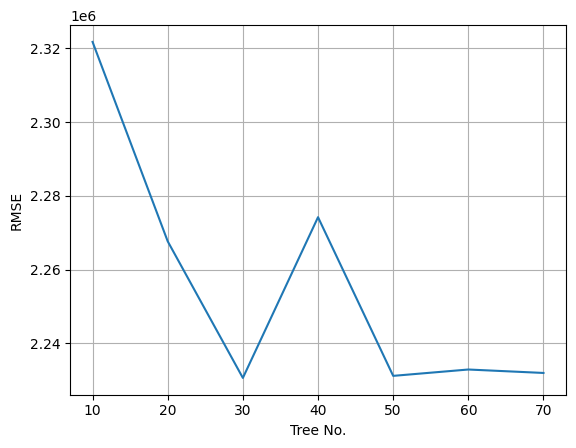

In [ ]:
plt.plot(num_trees, rmse_results)
plt.xlabel('Tree No.')
plt.ylabel('RMSE')
plt.grid()


From the graph, it seems 50 trees gives the best result along with not needing as much processing power as larger amounts

In [ ]:
numLoops = 100

mse_rf = np.zeros(numLoops)
rmpse_rf = np.zeros(numLoops)

np.random.seed(42)
for idx in range(0,numLoops):
  X_train, X_test, y_train, y_test = train_test_split( X, y, test_size = 0.2 )
  model = RandomForestRegressor( n_estimators = 50 )
  model.fit( X_train, y_train )
  y_pred = model.predict( X_test )
  mse_rf[idx] = np.sqrt(mean_squared_error( y_test, y_pred ))
  rmpse_rf[idx] = (np.sqrt(np.mean(np.square((y_test - y_pred) / y_test)))) * 100

print(f'RMSE: {(mse_rf).mean()}')
print(f'RMPSE: {rmpse_rf.mean()}')

RMSE: 2231163.7506847912
RMPSE: 25.098538349992733


With random forest, we get an RMPSE of around 25!

### XG Boost

In [ ]:
import xgboost as xgb

numLoops = 100
mse_xgb  = np.zeros(numLoops)
rmpse_xgb = np.zeros(numLoops)



# for idx in range(0,numLoops):
#   X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20)
#   xgbr = xgb.XGBRegressor(objective ='reg:squarederror', verbosity=0, seed = 42)
#   xgbr.fit(X_train,y_train)
#   y_pred_xgb = xgbr.predict(X_test)
#   mse_xgb[idx] = np.sqrt(mean_squared_error(y_test,y_pred_xgb))
#   rmpse_xgb[idx] = (np.sqrt(np.mean(np.square((y_test - y_pred) / y_test)))) * 100

# print(f'RMSE: {(mse_xgb).mean()}')
# print(f'RMPSE: {rmpse_xgb.mean()}')

XB Boost's RMSE is quite poor.. fortunately we can change some parameters to help with that

In [ ]:
from sklearn.model_selection import GridSearchCV

param_test = {
 'max_depth'     : [ 3, 4, 5, 6, 7 ],
 'learning_rate' : [ 0.1, 0.2, 0.3, 0.4 ],
 'n_estimators'  : [ 20, 40, 60, 80, 100, 120, 140 ],
}

# Perform the grid search
gsearch = GridSearchCV(
    estimator = xgb.XGBRegressor( objective = 'reg:squarederror', seed = 10 ),
    param_grid = param_test,
    scoring = 'neg_mean_squared_error',
    cv = 5,
)

# Fit to training data
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.05, random_state = 42 )
model = gsearch.fit(X_train,y_train)

# See grid search results
print(model.best_params_)


{'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 120}


After some tweaking, it seems having less depth and learning rate but more estimators minimizes the amount of errors!

In [ ]:

numLoops = 100
mse_xgb  = np.zeros(numLoops)

for idx in range(0,numLoops):
  X_train, X_test, y_train, y_test = train_test_split( X, y, test_size = 0.15 )
  xgbr = xgb.XGBRegressor(
      objective ='reg:squarederror',
      verbosity=0,
      **params,
      seed = 42,
  )
  y_train_log = np.log(y_train)

  xgbr.fit(X_train,y_train_log)
  y_pred_xgb = xgbr.predict(X_test)
  y_pred_xgb = np.exp(y_pred_xgb)

  mse_xgb[idx] = np.sqrt(mean_squared_error(y_test,y_pred_xgb))
  rmpse_xgb[idx] = (np.sqrt(np.mean(np.square((y_test - y_pred_xgb) / y_test)))) * 100

print(f'RMSE: {(mse_xgb).mean()}')
print(f'RMPSE: {rmpse_xgb.mean()}')


RMSE: 2167276.8316891124
RMPSE: 20.292894811501757


With properly tuned parameters, I got an RMPSE of 20, the best of all models!

### Decision Tree

In [ ]:
# max_depths = [1,2,3,4,5,6,7,8]
# rms_depth = np.zeros(len(max_depths))
# rmpse_depth = np.zeros(len(max_depths))

# numLoops = 100

# for n, depth in enumerate(max_depths):
#   rms_error = np.zeros(numLoops)

#   for idx in range(numLoops):
#     X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)
#     model = DecisionTreeRegressor(max_depth=depth)
#     model.fit(X_train,y_train)
#     y_pred = model.predict(X_test)
#     rms_error[idx] = np.sqrt(mean_squared_error(y_test, y_pred))

#   rms_depth[n] = rms_error.mean()





Now for decision tree!  For this, it's best to test which depth works the best

In [ ]:

# plt.plot(max_depths, rms_depth)
# plt.xlabel('Max Depth')
# plt.ylabel('RMSE')
# plt.grid()



Through a few tests, it seems a depth of 6 gives the best result!

In [ ]:
numLoops = 500

mse_rf = np.zeros(numLoops)
rmpse_rf = np.zeros(numLoops)


for idx in range(0,numLoops):
  X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)
  model = DecisionTreeRegressor(max_depth=6)
  model.fit(X_train,y_train)
  y_pred = model.predict(X_test)
  mse_rf[idx] = np.sqrt(mean_squared_error(y_test, y_pred))
  rmpse_rf[idx] = (np.sqrt(np.mean(np.square((y_test - y_pred) / y_test)))) * 100

rms = mse_rf.mean()
rmpse = rmpse_rf.mean()

print(f'RMSE: {rms}')
print(f'RMPSE: {rmpse}')

RMSE: 2664095.4301142683
RMPSE: 30.867664447842653


Decision tree's RMPSE is noticably higher than the other two models, with its biggest benefits really being that it runs faster

## Results

Of all the models, XB Boost gave the best result with an RMPSE of 23